In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

#Scikit-Learn

Scikit-Learn — это Python-библиотека, разработанная David Cournapeau в 2007 году и содкржит большое количество алгоритмов для задач, связанных с классификацией и машинным обучением в целом.

Scikit-Learn базируется на библиотеке SciPy, которую нужно установить перед началом работы

Установка:

In [2]:
# !pip install scikit-learn
# в колаборатории этого можно не делать, в своей локальной среде необходимо обеспечить установку пакета и всех его зависимостей


### Наборы данных

Для хранения наборов данных scikit learn  :
  - использует массивы в формате numpy.array ( из библиотеки NymPy)
  - использует разреженные матрицы в формате scipy.sparse (из библиотеки SciPy)
  - поддерживает формат хранения DataFrame из библиотеки Pandas
  - имеет функции, позволяющие считывать данные из внешних файлов в форматах txt, csv, json и так далее.
  - использует наборы данных, которые поставляются вместе с библиотекой. Это открытые общеизвестные данные:
      - **данные о стоимости жилья в Бостоне**: исходя из количества комнат и уровня преступности в городе, модель может вычислять цены на жилье;
      - **данные о результатах диагностики рака молочных желез** из города Висконсина: используются для выявления злокачественного или доброкачественного новообразования;
      - **датасет химических свойств вин**: исходя из этих свойств модель может определить тип вина.


### **Задание 1.** Знакомимся с методами получения данных внутри пакета scikit learn.

  1.1. Загрузить набор **стоимость жилья в Бостоне**.







In [3]:
from sklearn.datasets import fetch_california_housing

import sklearn.datasets as datasets

V = fetch_california_housing()

In [4]:
V

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [5]:
V.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [6]:
x = V['data']
y = V['target']
x.shape, y.shape  # x - описание объектов, у - стоимость объектов

((20640, 8), (20640,))

In [7]:
print(V['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [8]:
dfx = pd.DataFrame(V['data'], columns = V.feature_names)
dfx.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
dfy = pd.DataFrame(V["target"], columns = V['target_names'])

## Разведочный анализ данных, или EDA


**Цели EDA:**

1. Понимание структуры и характеристик набора данных / изучаем структуру и характеристики данных, чтобы полностью понять, с чем имеем дело:
    - обзор размера набора данных, типов переменных,
    - наличия пропущенных значений, дубликатов и других аспектов данных, иногда вполне субъективных, что будет основой для дальнейшего анализа.

2. Выявление аномалий и выбросов / поиск особенностей не регулярных и редких или странных (значения, отклоняющиеся от общего паттерна из-за ошибок ввода, случайных событий или даже указывающих на систематические проблемы в сборе данных). Определение и устранение таких аномалий становится критической частью нашего анализа, чтобы гарантировать надежность результатов.

3. Идентификация связей и корреляций между переменными:
    - статистические меры позволяет идентифицировать взаимосвязи между переменными,
    - поможет выдвинуть гипотезы и принятия решений.

4. Подготовка данных для дальнейших этапов анализа:
    - обрабатываем данные для того, чтобы подготовить их к более сложным аналитическим методам.
    - чистим данные от шума,
    - заполняем пропущенные значения,
    - проводим масштабирование или преобразования переменных, чтобы обеспечить их качественную и интерпретируемую структуру.
    
    
    Данные все - алгоритмы только помощь при анализе данных.
    
    
### Инструменты и методы разведочного анализа данных (EDA)

**библитотеки**:
1. Pandas - таблицы
2. Matplotlib - визуализация
3. Seaborn - красивая визуализация
4. Plotly - очень красивая визуализация
5. Pandas-profile - таблицы и визуализации
6. statsmodel - статистика
7. scipy - статистика и многое еще чего
8. .......
   

**1. Визуализация данных**

   - Гистограммы и диаграммы рассеяния    

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

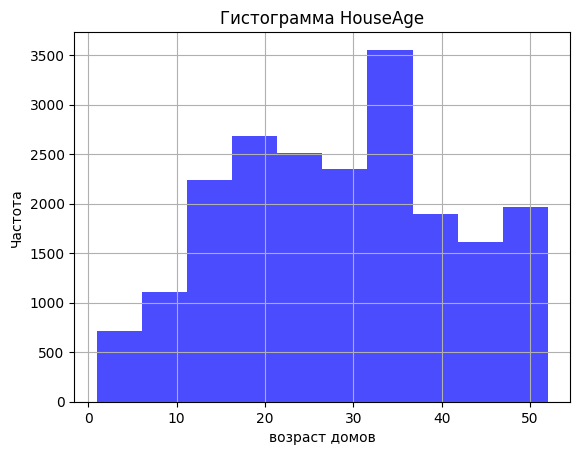

In [11]:
# Построение гистограммы
plt.hist(dfx.HouseAge, bins=10, color='blue', alpha=0.7)
plt.xlabel('возраст домов')
plt.ylabel('Частота')
plt.title('Гистограмма HouseAge' )
plt.grid()
plt.show()


 - Ящик с усами (box plot)

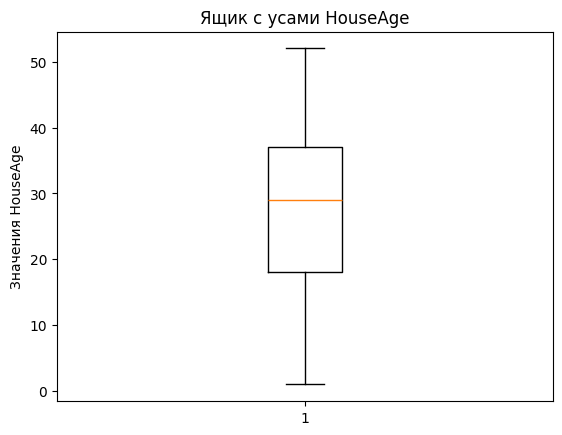

In [12]:
# Построение ящика с усами
plt.boxplot(dfx.HouseAge)
plt.ylabel('Значения HouseAge')
plt.title('Ящик с усами HouseAge')
plt.show()

   - Тепловые карты (heatmap)

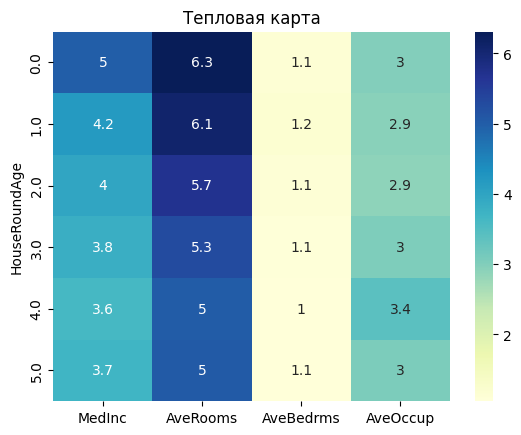

In [13]:
dfx['HouseRoundAge'] = np.round(dfx.HouseAge.values / 10)
# Построение тепловой карты
sns.heatmap(dfx.loc[:,['MedInc','AveRooms','AveBedrms','AveOccup','HouseRoundAge']].groupby(['HouseRoundAge']).mean(), annot=True, cmap='YlGnBu')
plt.title('Тепловая карта')
plt.show()

**2. Сводные статистики и меры центральной тенденции**

Сводные статистики и меры центральной тенденции позволяют нам получить обобщенное представление о распределении данных и основных характеристиках. Это ключевые числовые метрики, которые помогают нам понять типичные и наиболее значимые значения в наборе данных.

- Среднее (Mean): Это сумма всех значений, разделенная на количество значений. Оно представляет общую "среднюю" величину данных.

- Медиана (Median): Это среднее значение двух средних значений, если количество значений четное, или среднее значение самого центрального числа, если количество значений нечетное. Медиана предоставляет более устойчивую меру центральной тенденции в присутствии выбросов.

- Мода (Mode): Это значение, которое встречается наиболее часто в наборе данных. Мода может быть полезна для определения наиболее типичного значения.

In [20]:
from scipy import stats


# Расчет среднего
mean = np.mean(dfx.HouseAge)
print("Среднее:", mean)

# Расчет медианы
median = np.median(dfx.HouseAge)
print("Медиана:", median)

# Расчет моды
mode = stats.mode(dfx.HouseAge)
print("Мода:", mode.mode)

NameError: name 'dfx' is not defined

In [15]:
dfx.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseRoundAge
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.874758
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.268828
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.000000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,2.000000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,3.000000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,4.000000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000000


**3. Корреляционный анализ**

Корреляционный анализ помогает нам понять, какие переменные взаимосвязаны между собой и насколько сильна эта связь. Коэффициент корреляции измеряет степень линейной зависимости между двумя переменными.

- Положительная корреляция: Если одна переменная увеличивается, другая также увеличивается. Коэффициент корреляции находится в диапазоне от 0 до 1.

- Отрицательная корреляция: Если одна переменная увеличивается, другая уменьшается. Коэффициент корреляции находится в диапазоне от 0 до -1.

- Нулевая корреляция: Отсутствие линейной зависимости между переменными. Коэффициент корреляции близок к 0.

Коэффициент корреляции: 0.01319135663602974


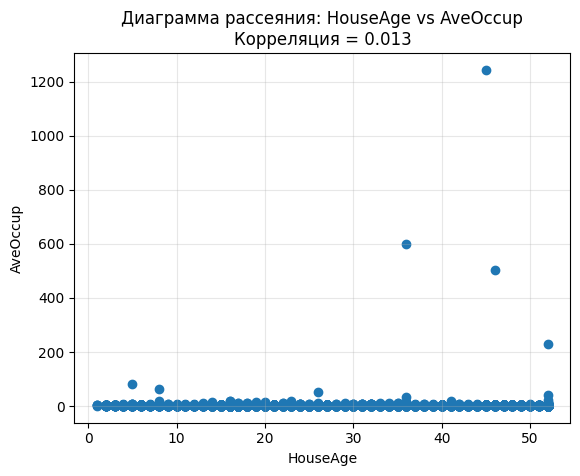

In [16]:
correlation = np.corrcoef(dfx.HouseAge, dfx.AveOccup)[0, 1]
print("Коэффициент корреляции:", correlation)

# Визуализация данных
plt.scatter(dfx.HouseAge, dfx.AveOccup)
plt.xlabel('HouseAge')
plt.ylabel('AveOccup')
plt.title(f'Диаграмма рассеяния: HouseAge vs AveOccup\nКорреляция = {correlation:.3f}')
plt.grid(alpha=0.3)
plt.show()

Коэффициент корреляции: -0.04670051296948687


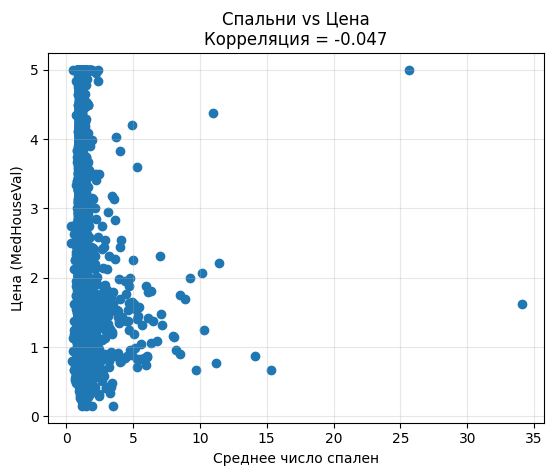

In [17]:
correlation = np.corrcoef(dfx.AveBedrms, y)[0, 1]
print("Коэффициент корреляции:", correlation)

# Визуализация данных
plt.scatter(dfx.AveBedrms, y)
plt.xlabel('Среднее число спален')
plt.ylabel('Цена (MedHouseVal)')
plt.title(f'Спальни vs Цена\nКорреляция = {correlation:.3f}')
plt.grid(alpha=0.3)
plt.show()

Коэффициент корреляции: 0.6880752079585479


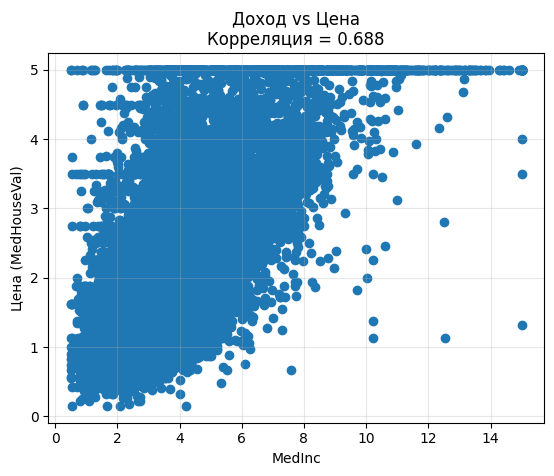

In [18]:
correlation = np.corrcoef(dfx.MedInc, y)[0, 1]
print("Коэффициент корреляции:", correlation)

# Визуализация данных
plt.scatter(dfx.MedInc, y)
plt.xlabel('MedInc')
plt.ylabel('Цена (MedHouseVal)')
plt.title(f'Доход vs Цена\nКорреляция = {correlation:.3f}')
plt.grid(alpha=0.3)
plt.show()

все сразу!!!!

In [19]:
help(sns.pairplot)

Help on function pairplot in module seaborn.axisgrid:

pairplot(data, *, hue=None, hue_order=None, palette=None, vars=None, x_vars=None, y_vars=None, kind='scatter', diag_kind='auto', markers=None, height=2.5, aspect=1, corner=False, dropna=False, plot_kws=None, diag_kws=None, grid_kws=None, size=None)
    Plot pairwise relationships in a dataset.
    
    By default, this function will create a grid of Axes such that each numeric
    variable in ``data`` will by shared across the y-axes across a single row and
    the x-axes across a single column. The diagonal plots are treated
    differently: a univariate distribution plot is drawn to show the marginal
    distribution of the data in each column.
    
    It is also possible to show a subset of variables or plot different
    variables on the rows and columns.
    
    This is a high-level interface for :class:`PairGrid` that is intended to
    make it easy to draw a few common styles. You should use :class:`PairGrid`
    directly 

In [ ]:
sns.pairplot(pd.concat([dfx,dfy], axis=1), hue=list(dfy.columns)[0])

**5. Преобразование данных (например, нормализация или стандартизация)**

Преобразование данных – это процесс изменения шкалы или распределения переменных, чтобы сделать их более подходящими для анализа или моделирования. Это важный этап EDA, который помогает сгладить различия между переменными и создать более устойчивые и интерпретируемые данные.

  - Нормализация (Normalization): Этот метод масштабирует значения переменных так, чтобы они находились в диапазоне от 0 до 1. Это особенно полезно, когда у нас есть переменные с разными единицами измерения и масштабами.

  - Стандартизация (Standardization): Этот метод преобразует значения переменных так, чтобы их среднее было равно 0, а стандартное отклонение – 1. Он делает распределение более "стандартным" и симметричным.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [ ]:
# Нормализация данных
scaler_m = MinMaxScaler()
normalized_data = scaler_m.fit_transform(dfx.HouseAge.values.reshape(-1,1))
print("Нормализованные данные:")
plt.figure(figsize = (16,5))
plt.hist(normalized_data, label = 'Нормализованные данные')
plt.hist(dfx.HouseAge.values, label = 'raw данные', alpha = 0.3)
plt.grid()
plt.legend()
plt.show()

# Стандартизация данных
scaler_s = StandardScaler()
standardized_data = scaler_s.fit_transform(dfx.HouseAge.values.reshape(-1,1))
print("Стандартизованные данные:")
plt.figure(figsize = (16,5))
plt.hist(standardized_data, label = 'Стандартизованные данные')
plt.hist(dfx.HouseAge.values, label = 'raw данные', alpha = 0.3)
plt.grid()
plt.legend()
plt.show()

**6. Анализ выбросов и аномалий**

Анализ выбросов и аномалий – это процесс выявления и исследования значений данных, которые существенно отличаются от остальных наблюдений. Выбросы и аномалии могут возникнуть из-за ошибок в данных, случайных событий или указывать на особенности исследуемого явления.

Основные шаги анализа выбросов и аномалий:

  - Визуализация данных: Используйте графики, такие как ящик с усами (box plot) или диаграммы рассеяния, чтобы визуально выявить потенциальные выбросы.

  - Статистический анализ: Используйте статистические методы, чтобы определить, какие значения считаются выбросами на основе критериев (интерквартильный размах,  Z-оценка).

  - Принятие решения: Решите, какие действия необходимо предпринять с выбросами, например, удалить их, заменить на другие значения или оставить без изменений.



In [ ]:
# Построение ящика с усами
plt.boxplot(y)
plt.ylabel('Значения')
plt.title('Анализ выбросов')
plt.show()

In [ ]:
import sklearn as sk

## Шаги разведочного анализа данных

1. Загрузка и первичный осмотр данных

  - загрузка

In [ ]:
V = sk.datasets.fetch_kddcup99()#as_frame = True, subset = 'SA')

# V.frame.head()
# df = V.frame

In [ ]:
V.target_names

In [ ]:
V['data'].shape

In [ ]:
df = pd.DataFrame(V['data'], columns = V.feature_names)
df[V.target_names[0]] = V.target
df.head()

In [ ]:
print(V.DESCR)

In [ ]:
df.shape

In [ ]:
# V = fetch_california_housing(as_frame = True)

# dfx = pd.DataFrame(V['data'], columns = V.feature_names)




- осмотр

In [ ]:
df.head()

In [ ]:

df.info()

**2. Обработка пропущенных значений, дубликатов и коррекция типов**

In [ ]:
df.shape

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.shape

нет дублей

In [ ]:
df.isnull().mean() * 100

нет признаков, у которых много пропусков (при значениях 50 и более - признак удаляем )


In [ ]:
list_to_del = df.isnull().mean() * 100
type(list_to_del)

In [ ]:
for name in df.columns:
    if list_to_del[name] > 50:
        print(name)
        df.drop(name,axis = 1, inplace = True)

замена типов:

In [ ]:
for name in df.columns:
    try:
        df[name] = df[name].values.astype('float')
    except:
        print(name)

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.labels.unique()

In [ ]:
dict_to_ch = {name:i for i,name in enumerate(df.labels.unique())}
dict_to_ch

In [ ]:
y = [ dict_to_ch[k] for k in df.labels.values ]
y[:10]


In [ ]:
df.labels = y

In [ ]:
df.info()

In [ ]:
list_numb = []
for name in df.columns:
    print(name, len(df[name].unique()))
    list_numb += [len(df[name].unique())]


In [ ]:
np.median(list_numb), np.mean(list_numb)

In [ ]:
plt.plot( list_numb)
plt.ylabel('num')
plt.show()

In [ ]:

for name in df.columns:
    print(name, len(df[name].unique()))
    if len(df[name].unique())<np.mean(list_numb) and isinstance(df[name].values[0], float):
        df[name] = df[name].values.astype('int')

In [ ]:
df.info()

**3. Анализ распределения переменных**

 - будем изучать распределение числовых переменных.
 - построим гистограммы, Q-Q диаграммы и диаграммы рассеяния для лучшего понимания данных.

In [ ]:
df.describe()

Посмотреть на все признаки:

In [19]:
import statsmodels.api as sm
import scipy.stats as stats

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
float_col = df.select_dtypes(include=['float'])

Q-Q plot и тест гипотез (тип закона распределения):

In [ ]:
for name in float_col.columns:
    try:
        plt.figure(figsize = (16,5))
        plt.subplot(1,2,1)
        plt.hist(df[name])
        plt.title(name)
        plt.grid()
        plt.xlabel(name)

        plt.subplot(1,2,2)
        plt.scatter( df['labels'],df[name])
        plt.title(name)
        plt.grid()
        plt.xlabel('labels')
        plt.ylabel(name)
        plt.show()

        # варианты
        fig, ax = plt.subplots(1, 3, figsize=(16, 5))
        # нормальный закон
        fig = sm.qqplot(df[name], line='s', ax=ax[0])
        ax[0].set_title(name + ' q-q normal line=s')
        ax[0].grid()
        # plt.show()

        # нормальный закон
        fig = sm.qqplot(np.log(df[name].values + df[name].min() + 0.001), line='s', ax=ax[1])
        ax[1].grid()
        ax[1].set_title("log_" + name + 'q-q normal line=s')

        # Гамма закон
        dist = stats.gamma(5)
        fig = sm.qqplot(df[name],  ax=ax[2], dist=dist , line='q', fit=False)
        ax[2].grid()
        ax[2].set_title(name + ' q-q normal')

        plt.show()


        stat, p = stats.shapiro(x)
        alpha = 0.05
        if p > alpha:
            print('normal : shapiro result:',stat, p)

        stat, p = stats.kstest(x, 'norm')
        if p > alpha:
            print('normal : Колмогоров result:',stat, p)

        stat, p = stats.normaltest(x) # Критерий согласия Пирсона
        if p > alpha:
            print('normal :  Пирсон-тест: Statistics=%.3f, p-value=%.3f' % (stat, p))


    except:
        print(name)

Пример нормальный закон:
    N изменяем от 100 до 1000

In [ ]:
N = 100
x = np.random.normal(loc=8.25, scale=3.5, size=N)
y = np.random.normal(loc=8.00, scale=3.25, size=N*2)
pp_x = sm.ProbPlot(x, fit=True)
pp_y = sm.ProbPlot(y, fit=True)

#
fig2 = pp_x.probplot(exceed=False)

# compare x quantiles to y quantiles
fig3 = pp_x.qqplot(other=pp_y, line='45')

# same as above with probabilities/percentiles
fig4 = pp_x.ppplot(other=pp_y, line='45')

stat, p = stats.shapiro(x)
alpha = 0.05
if p > alpha:
    print('normal : shapiro result: Statistics=%.3f, p-value=%.3f' %(stat, p))

stat, p = stats.kstest(x, 'norm')
if p > alpha:
    print('normal : Колмогоров result: Statistics=%.3f, p-value=%.3f' %(stat, p))

stat, p = stats.normaltest(x) # Критерий согласия Пирсона
if p > alpha:
    print('normal :  Пирсон-тест: Statistics=%.3f, p-value=%.3f' % (stat, p))


**4. Исследование корреляций между переменными**
 - используем коэффициент корреляции, чтобы определить, какие переменные взаимосвязаны.

In [ ]:
df.head()

In [ ]:
float_col

In [ ]:
s_cor = float_col.corr().abs()

In [ ]:
sns.heatmap(s_cor)

In [ ]:
df.num_outbound_cmds.unique()

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

**5. Выявление выбросов и аномалий**

     - ящик с усами (box plot).



In [ ]:
sns.boxplot(df['num_compromised'])

In [ ]:
for name in float_col.columns:
    try:
        if isinstance(df[name].values[0], float) or isinstance(df[name].values[0], np.int64):
            sns.boxplot(df[name].values)
            plt.title(name)
            plt.show()
    except:
        print(name)

**6. Изучение категориальных переменных**



In [ ]:
cat_col = df.select_dtypes(include=['object', 'int'])

In [ ]:
for name in cat_col.columns[:-1]:

    try:
        if not isinstance(df[name].values[0], float) :
            product_counts = df[name].value_counts()
            product_counts.plot(kind='bar')
            plt.xlabel('значение')
            plt.ylabel('количество значений')
            plt.title('Частота значений '+name)
            plt.xticks(rotation=45)
            plt.show()
    except:

        print(name)


**7. Обзор результатов EDA**

- гипотезы о распредлелениях
- предложения о способах заполнения пробелов , если они есть

## Задания для работы:

Задание 1.

1.1 Загрузить данные

1.2. Вывести таблицу с описанием данных и определить характер целевого свойства и оценить полноту данных

1.3. Постоить гистограмму для цели

1.4. построить гистограммы для признаков

1.5. Сделать визуальную оценку характера распределения

1.6. Оценить характер распределения опираясь на тесты нормальности

1.7. Определить основной набор статистик для х и у

1.8. Оцените факт наличия/отсутствия выбросов и охарактеризуйте качество данных (резюме предществующих пунктов )


# 1.1

In [1]:
from sklearn.datasets import load_diabetes, load_iris, load_breast_cancer
from sklearn.datasets import make_blobs
from sklearn.datasets import make_classification
from sklearn.datasets import make_circles, make_moons
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

Выбрать один из вариантов.

In [2]:
x, y  = load_diabetes(return_X_y=True)

In [3]:
#1.2
pd.DataFrame(x).head()

,0,1,2,3,4,5,6,7,8,9
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [4]:
pd.DataFrame(x).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       442 non-null    float64
 1   1       442 non-null    float64
 2   2       442 non-null    float64
 3   3       442 non-null    float64
 4   4       442 non-null    float64
 5   5       442 non-null    float64
 6   6       442 non-null    float64
 7   7       442 non-null    float64
 8   8       442 non-null    float64
 9   9       442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


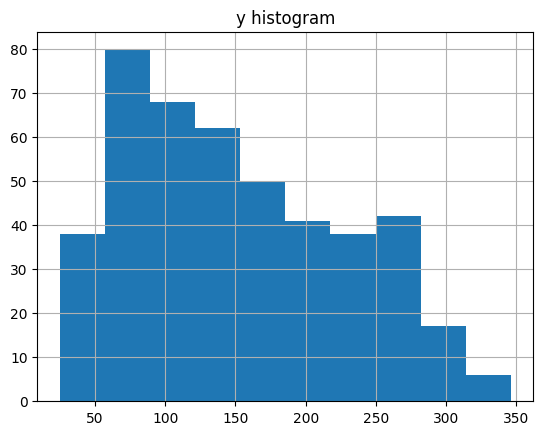

In [5]:
#1.3
plt.hist(y)
plt.grid()
plt.title('y histogram')
plt.show()

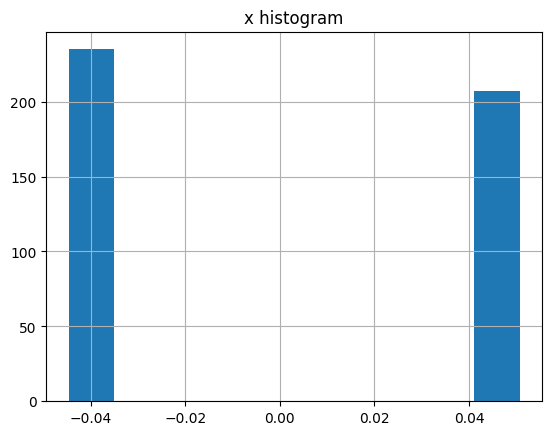

In [6]:
#1.4  построить по аналогии все признаки и описать
plt.hist(x[:,1])
plt.grid()
plt.title('x histogram')
plt.show()

1.5. Распределение по y одномодальное, но скошено вправо — много значений в районе 50–150 и длинный «хвост» вправо, непрерывное. 
     Распределение по x является почти бинарным, непрерывным не является.

In [7]:
# 1.6
stat, p = stats.shapiro(y)
p

np.float64(3.3635438799024454e-11)

In [8]:
# 1.7.

pd.DataFrame(y).describe()

,0
count,442.000000
mean,152.133484
std,77.093005
min,25.000000
25%,87.000000
50%,140.500000
75%,211.500000
max,346.000000


In [9]:
pd.DataFrame(x).describe()

,0,1,2,3,4,5,6,7,8,9
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


1.8. Оценка набора данных:

Анализ данных показавает, что в наборе отсутствуют пропуски, а все признаки представлены в числовом формате. Признаковые данные распределены компактно и не содержат значений, выходящих за рамки трёх стандартных отклонений(если какое-то значение выходит за границы mean +- 3*std, то оно очень редко встречается и может считаться выбросом.), из чего можно сделать вывод об отсутствии сильных выбросов. Однако можем заметить у признаков 2 и 4-9 точки выше или ниже усов(слабые выбросы), но их количество незначительно и они не оказывают существенного влияния на общую структуру данных. В целом данные высокого класса:полные, чистые.

In [ ]:
X = pd.DataFrame(x, columns=[f'feat_{i}' for i in range(x.shape[1])])

plt.figure(figsize=(12, 5))
X.boxplot(rot=0)
plt.title("Boxplot по признакам")
plt.grid(True, axis='y')
plt.show()



Можно формировать синтетические наборы данных из datasets.make_classification (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html#sklearn.datasets.make_classification). Каждый класс состоит из ряда гауссовых кластеров, каждый из которых расположен вокруг вершин гиперкуба в подпространстве размерности n_informative. Для каждого кластера информативные признаки рисуются независимо от N(0, 1), а затем случайным образом линейно комбинируются внутри каждого кластера для добавления ковариации. Затем кластеры размещаются в вершинах гиперкуба. Основные параметры для настройки генереируемых наборов:
  - n_samples=100, по умолчанию = 100
Количество образцов.
  - n_features=20, Общее количество признаков
  - n_informative=2, Количество информативных признаков.
  - n_redundant=2, Количество избыточных признаков (генерируются как случайные линейные комбинации информативных признаков)
  - n_classes=2,Количество классов (или меток) задачи классификации
  - n_clusters_per_class=2,Количество кластеров на класс
  - shuffle=True, Перемешаем объекты
  - random_state=None - зерно генератора случайных чисел


  Построим примеры синтетических наборов:



In [ ]:
from sklearn import datasets
# 100 примеров, 2 информативных признака, нет избыточных признаков, 2 класса и один кластер на класс

X, y = datasets.make_classification(n_features=2, n_redundant=0, n_informative=2,random_state=1, n_clusters_per_class=1)

plt.scatter(X[:,0],X[:,1],c = y)
plt.grid()
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

In [ ]:
# 1000 примеров, 10 информативных признака, 2 избыточных признакf, 2 класса и 2 кластер на класс

X, y = datasets.make_classification(n_samples = 1000, n_features=10, n_redundant=2, n_informative=2,random_state=1, n_clusters_per_class=2)

plt.scatter(X[:,0],X[:,1],c = y)
plt.grid()
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

Генерация гаусовой смеси через sklearn.datasets.make_blobs позволяет строить похожие на реальные еэкземпляры датасетов. Не является в явной форме классификационным набором данных, но можно успешно использовать для генерации синтетических данных классификационных задач, т.к. возвращает и описание объектов и у-принадлежность источнику. Позволит построить сравнительно сложные для классификации задачи.  Для настройки использует следующие параметры:

  - n_samples=100, по умолчанию = 100
Количество образцов.
  - n_features=20, Общее количество признаков
  - centers=None,Количество гаусовых источников (центров нормальных распределений для генерации данных)
  - cluster_std = 1.,характеристика рассеивания (стандартное отклонение)
  - shuffle=True, Перемешаем объекты
  - random_state=None - зерно генератора случайных чисел

In [ ]:
X, y = datasets.make_blobs(n_samples=100, centers=4, n_features=2, random_state=0)

plt.scatter(X[:,0],X[:,1],c = y)
plt.grid()
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

### **Задание 2.** Знакомимся с методами генерации данных внутри пакета scikit learn.

2.1 Создать синтетический набор данных для классификации на основе datasets.make_classification с числом классов 2, 2 мя информативными признаками и 3-мя избыточными, определить по 2 кластера в каждом классе и число примеров 1000

2.2. Провести анализ полученных признаков : основные статистики, гистограммы, оценка нормальности

2.3 Создать синтетический набор данных для классификации на основе datasets.make_blobs с числом источников 3, 2-мя  признаками и числом примеров 1000

2.4. Провести анализ полученных признаков : основные статистики, гистограммы, оценка нормальности

In [ ]:
#2.1
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
from scipy import stats

X, y = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=2,
    n_redundant=3,
    n_classes=2,
    n_clusters_per_class=2,
    random_state=57
)

df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['target'] = y

df.head()

In [ ]:
#2.2
summary = df.describe(include='all')
print("Статистическое резюме:\n", summary)

df.hist(figsize=(12, 8))
plt.show()

print("\nПроверка на нормальность:")
for column in df.columns[:-1]:
    stat, p_value = stats.shapiro(df[column])
    if p_value > 0.05:
        result = "распределение близко к нормальному"
    else:
        result = "распределение отклоняется от нормального"
    stat, p = stats.kstest(df[column], 'norm')
    if p > 0.05:
        print('normal : Колмогоров result:',stat, p)
    stat, p = stats.normaltest(df[column])
    if p > 0.05:
        print('normal :  Пирсон-тест: Statistics=%.3f, p-value=%.3f' % (stat, p))
    print(f"{column}: p-value={p_value:.4f} → {result}")

In [ ]:
#2.3
from sklearn.datasets import make_blobs

X_blobs, y_blobs = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=3,
    random_state=58
)

df_blobs = pd.DataFrame(X_blobs, columns=['feature_1', 'feature_2'])
df_blobs['target'] = y_blobs

print(df_blobs.head())

plt.scatter(X_blobs[:,0],X_blobs[:,1],c = y_blobs)
plt.grid()
plt.xlabel('feature_1')
plt.ylabel('feature_2')
plt.show()

In [ ]:
#2.4
summary_blobs = df_blobs.describe(include='all')
print("Статистическое резюме:\n", summary_blobs)

df_blobs.hist(figsize=(10, 6))
plt.show()

print("\nПроверка на нормальность):")
for column in df_blobs.columns[:-1]:
    stat, p_value = stats.shapiro(df[column])
    if p_value > 0.05:
        result = "распределение близко к нормальному"
    else:
        result = "распределение отклоняется от нормального"
    stat, p = stats.kstest(df[column], 'norm')
    if p > 0.05:
        print('normal : Колмогоров result:',stat, p)
    stat, p = stats.normaltest(df[column])
    if p > 0.05:
        print('normal :  Пирсон-тест: Statistics=%.3f, p-value=%.3f' % (stat, p))
    print(f"{column}: p-value={p_value:.4f} → {result}")

 ### Задание 3. ДЗ

In [ ]:
#3.1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
df = pd.read_csv('avocado.csv')
df

In [ ]:
#3.2
df.head()

In [ ]:
#3.3
df.info()

df.describe()

In [ ]:
#3.4
print("Размерность данных:", df.shape)

target = 'AveragePrice'
features = [col for col in df.columns if col not in ['AveragePrice']]

print("Целевая переменная:", target)
print("Предикторы:", features)

In [ ]:
#3.5
summary = df.describe()
print("Основные статистики по числовым признакам:\n", summary)

df.hist(figsize=(12, 8))
plt.show()

print("\nПроверка нормальности распределений:")
for column in df.select_dtypes(include='number').columns:
    stat, p_value = stats.shapiro(df[column])
    verdict = "близко к нормальному" if p_value > 0.05 else "отклоняется от нормального"
    print(f"{column}: p-value={p_value:.4f} → {verdict}")


In [41]:
#3.6
df.isna().sum()

Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

Регрессия: предсказать AveragePrice по остальным признакам
(Построить модель, предсказывающую среднюю цену авокадо (AveragePrice) на основе данных о продажах, типе продукта и регионе.)

Регрессия: предсказать AveragePrice по остальным признакам
(Построить модель, предсказывающую среднюю цену авокадо (AveragePrice) на основе данных о продажах, типе продукта и регионе.)